<a href="https://colab.research.google.com/github/lbeckman314/resume/blob/main/demo/metro_finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Oregon Metro AI Assistant — Fine-Tuning Demo

**Purpose:** Demonstrate the full Unsloth fine-tuning pipeline for the Oregon Metro AI Automation Specialist role.

**Pipeline:**
```
metro_qa_dataset.jsonl  →  Unsloth LoRA fine-tune  →  Merged adapter  →  Sample inference
       (10 Metro Q&A pairs)     (Gemma-3 1B, ~5 min on T4)
```

**Runtime:** Google Colab T4 GPU (free tier). Set `Runtime > Change runtime type > T4 GPU` before running.

---

## 1. Install Unsloth

In [ ]:
%%capture
# Unsloth recommends installing via their pinned wheel for Colab stability
import subprocess, sys

subprocess.run([
    sys.executable, "-m", "pip", "install",
    "unsloth[colab-new]",
    "--quiet"
], check=True)

# Also install trl for SFTTrainer
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "trl", "datasets",
    "--quiet"
], check=True)

print("Installation complete.")

## 2. Load Model with Unsloth

We use **Gemma-3 1B Instruct** — small enough to fine-tune in ~5 minutes on a free T4, and Unsloth has native support for it.

Unsloth's `FastLanguageModel` applies automatic LoRA patching and 4-bit quantization, reducing VRAM from ~6 GB to ~2.5 GB.

In [ ]:
from unsloth import FastLanguageModel
import torch

MAX_SEQ_LENGTH = 2048
MODEL_NAME = "unsloth/gemma-3-1b-it"  # Unsloth-optimized Gemma-3 1B Instruct

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,          # auto-detect: bfloat16 on Ampere+, float16 on T4
    load_in_4bit=True,   # 4-bit QLoRA — fits T4's 15 GB VRAM comfortably
)

print(f"Loaded: {MODEL_NAME}")
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

## 3. Apply LoRA Adapters

We freeze the base model and add trainable LoRA adapters to the attention and MLP layers. Only ~1-3% of parameters are trained — this is what makes fine-tuning feasible on a single GPU.

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,                      # LoRA rank — higher = more capacity, more VRAM
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0.0,          # Unsloth recommends 0 for speed
    bias="none",
    use_gradient_checkpointing="unsloth",  # Unsloth's memory-efficient checkpointing
    random_state=42,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} ({100 * trainable / total:.2f}% of {total:,} total)")

## 4. Load Metro Q&A Dataset

The dataset was generated as part of the Unsloth Studio Recipe (`metro_recipe.json`) and exported as JSONL.

Each row has a `conversations` field with `[{role: user, content: ...}, {role: assistant, content: ...}]`. We apply Gemma-3's chat template to format it for training.

In [ ]:
import json
from datasets import Dataset

# Inline dataset — same content as metro_qa_dataset.jsonl
# In production: load from the Unsloth Studio JSONL output
RAW_DATA = [
    {"conversations": [{"role": "user", "content": "A resident called asking whether the Springwater Corridor trail near their home is maintained by Metro or by the City of Portland. How do I look this up?"}, {"role": "assistant", "content": "The Springwater Corridor is jointly managed — Metro owns most of the trail corridor as part of its regional parks system, but the City of Portland maintains the segment within city limits through a maintenance agreement. To confirm a specific segment: open the Metro RLIS Discovery portal, search for the 'Regional Trails' layer, and click the trail segment in question. The 'Jurisdiction' and 'Maintainer' attributes will show the responsible party. If the segment lacks attributes, check the underlying parcel ownership via the 'Taxlots' layer and cross-reference with Metro's Parks & Nature asset inventory. Document your lookup and the resident's address in the service request log for the public records trail."}]},
    {"conversations": [{"role": "user", "content": "We need to send a reminder to all permit applicants whose land-use applications have been pending for more than 90 days. Can we automate this with Power Automate?"}, {"role": "assistant", "content": "Yes — this is a good fit for a scheduled Power Automate cloud flow. The pattern: use a Recurrence trigger (daily), query your permitting database or SharePoint list for records where 'SubmittedDate' is older than today minus 90 days and 'Status' is not 'Closed' or 'Approved', then send a templated email via the Office 365 Outlook connector. A few compliance notes before you ship it: confirm that applicant email addresses are stored in an approved system (not a personal spreadsheet), ensure the flow logs each send to a SharePoint audit list for public records purposes, and add a condition to skip applicants who have already received a reminder in the last 30 days to avoid harassment concerns. Have a planner review the email template before the first run."}]},
    {"conversations": [{"role": "user", "content": "Our GIS team wants to publish the updated urban growth boundary shapefile to the public RLIS download page. What's the review process before we make it live?"}, {"role": "assistant", "content": "For any RLIS dataset going to public download, the standard review steps are: (1) Data quality check — run the Metro QA script against the shapefile to validate geometry, attribute completeness, and vintage date. (2) Legal/policy review — the UGB is an adopted Metro planning boundary, so confirm that the version reflects the most recently acknowledged UGB amendment with Metro's Planning department before publishing. (3) Metadata — update the FGDC metadata record with the correct effective date, source ordinance number, and contact info. (4) IT Security sign-off — public downloads go through the approved static file hosting path, not a direct database connection. Submit the shapefile and metadata to the RLIS data steward for final approval."}]},
    {"conversations": [{"role": "user", "content": "I'm building a Copilot Studio agent for the solid waste team. It needs to answer questions about drop-off site hours. Where should it pull that data from, and do I need IT approval?"}, {"role": "assistant", "content": "The authoritative source for Metro solid waste drop-off hours is the Metro.org CMS, not a spreadsheet. For a Copilot Studio agent, the cleanest approach is to configure a knowledge source pointing at the public Metro.org pages for each drop-off site — Copilot Studio can crawl and index these via the 'Public website' connector. This keeps the agent automatically current when the web team updates hours. Before going live: yes, IT approval is required — submit a Copilot Studio agent deployment request through the IS governance intake process. You'll need to document the data sources, confirm no PII is collected in chat sessions, and get sign-off from the Solid Waste department lead. Also add a fallback message directing residents to call 503-234-3000 if the agent can't answer."}]},
    {"conversations": [{"role": "user", "content": "A council member's office is asking for a map showing all Metro-owned natural areas within a half-mile of schools in the tri-county area. How do I generate this?"}, {"role": "assistant", "content": "This is a standard buffer + intersect GIS workflow. In ArcGIS Pro or QGIS: (1) Load the Metro Natural Areas layer from RLIS. (2) Load school locations from the Oregon DOE data or the Metro RLIS 'Schools' point layer, filtered to active K-12 schools in Multnomah, Clackamas, and Washington counties. (3) Run a 0.5-mile (2,640 ft) buffer on the school points. (4) Intersect or Select by Location to find natural areas that overlap the buffer zones. (5) Export the result and produce a layout with a Metro basemap, scale bar, north arrow, and a data source note citing the RLIS vintage date. Before sending to the council office, have the Parks & Nature planner verify the natural area ownership attributes are current."}]},
    {"conversations": [{"role": "user", "content": "Can I use ChatGPT to summarize public comment letters we received on the 2040 Growth Concept update?"}, {"role": "assistant", "content": "Not with public ChatGPT — public comment letters submitted to Metro in a formal planning process are public records and may contain PII. Uploading them to a consumer AI tool sends that data to a third-party server outside Metro's data governance boundary. The approved path: use Azure OpenAI via Metro's IS-managed Azure tenant, where data stays within the Microsoft enterprise agreement boundary and does not train public models. IS can provision an Azure OpenAI Summarization flow in Power Automate or an n8n workflow that strips PII fields before summarization. Submit a request through the IS intake portal and mention the planning deadline."}]},
    {"conversations": [{"role": "user", "content": "We want to set up an AI chatbot on the Metro website to answer basic parks questions from the public. What are the key risks we need to address before launch?"}, {"role": "assistant", "content": "Key risks: (1) Accuracy — the bot must pull from a controlled knowledge source (Metro.org CMS), not generate freeform answers. Use RAG, not a plain LLM. (2) PII collection — chat logs may be public records under Oregon law; define a retention schedule and post a privacy notice. (3) Accessibility — the chat widget must meet WCAG 2.1 AA. (4) Escalation path — always provide a fallback contact (phone/email) when the bot can't answer. (5) IT governance — public-facing applications require IS security review and Deputy COO sign-off. Recommended MVP: staff-facing Teams pilot for 60 days first, then promote to public."}]},
    {"conversations": [{"role": "user", "content": "My Power Automate flow that pulls data from our Oracle database is failing with a connection timeout error. It worked last week. What should I check?"}, {"role": "assistant", "content": "A timeout that appeared suddenly almost always points to: (1) Credential expiration — check the connection in Power Automate under Data > Connections; re-authenticate if it shows a warning. (2) On-premises data gateway — if the Oracle DB is on-prem, check the gateway status in the Power Platform admin center; a stopped gateway service is the most common cause. (3) Network/firewall change — confirm with IS Networking that no rules changed on Oracle's port (default 1521). (4) Oracle DB maintenance — check with the DBA team whether a patch window or listener restart occurred. Start with the gateway status check — it takes 2 minutes and is the most common culprit."}]},
    {"conversations": [{"role": "user", "content": "How do I structure a prompt for a Copilot Studio agent so it only answers questions about Metro services and politely declines everything else?"}, {"role": "assistant", "content": "Use a system prompt with explicit scope boundaries. Paste this into the agent's Instructions field:\n\n```\nYou are Metro Assistant, an AI for Oregon Metro.\nYou ONLY answer questions about: Metro parks, trails, and natural areas; solid waste and recycling drop-off sites; regional land-use planning and the urban growth boundary; Metro-sponsored events and venues; how to contact Metro departments.\nIf a question is outside these topics, respond: \"I can only help with Oregon Metro services. You can reach Metro staff at oregonmetro.gov/contact.\"\nNever speculate, never provide legal or medical advice.\n```\n\nThen add Topics that map common intents to verified knowledge sources rather than letting the LLM answer freeform. The combination of a scoped system prompt plus grounded Topics is far more reliable than the system prompt alone."}]},
    {"conversations": [{"role": "user", "content": "We're evaluating n8n vs Power Automate for a workflow that calls an external REST API and writes results to a PostgreSQL database. Which should we use?"}, {"role": "assistant", "content": "For Metro's context, Power Automate is the default if the workflow is owned by a business team and needs to be maintainable without developer involvement. n8n is the better fit if the REST API requires custom auth logic that Power Automate's HTTP connector handles poorly, or the PostgreSQL write needs bulk upserts or transactions the Power Automate connector can't express. The practical tradeoff: n8n requires IS to provision a self-hosted instance; Power Automate has lower ops overhead but hits walls on complex API patterns. Recommendation: prototype the REST API call and PostgreSQL write in n8n locally first (Docker, under 10 minutes). If it works cleanly, bring that result to IS as justification for an n8n instance request."}]}
]

def format_conversation(example):
    """Apply Gemma-3 chat template to a conversations list."""
    text = tokenizer.apply_chat_template(
        example["conversations"],
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text}

raw_dataset = Dataset.from_list(RAW_DATA)
dataset = raw_dataset.map(format_conversation, remove_columns=["conversations"])

print(f"Dataset size: {len(dataset)} rows")
print("\n--- Sample formatted row (first 500 chars) ---")
print(dataset[0]["text"][:500])

## 5. Fine-Tune with SFTTrainer

We use HuggingFace `trl`'s `SFTTrainer` with Unsloth's patched model. Training runs for 3 epochs on 10 examples — enough to demonstrate the pipeline. A production run would use hundreds of Unsloth Studio-generated rows.

In [6]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    args=TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        num_train_epochs=3,
        warmup_steps=5,
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=1,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=42,
        output_dir="/tmp/metro-adapter",
        save_strategy="no",    # disable all checkpointing (avoids TRL/Unsloth pickle bug)
        report_to="none",
    ),
)

print("Starting fine-tuning...")
trainer_stats = trainer.train()

print(f"\nTraining complete in {trainer_stats.metrics['train_runtime']:.0f}s")
print(f"Final loss: {trainer_stats.metrics['train_loss']:.4f}")

Unsloth: Switching to float32 training since model cannot work with float16


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/10 [00:00<?, ? examples/s]

Starting fine-tuning...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10 | Num Epochs = 3 | Total steps = 6
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 13,045,760 of 1,012,931,712 (1.29% trained)


Step,Training Loss
1,4.224512
2,3.864982
3,4.089399
4,3.847151
5,3.632792
6,4.071924



Training complete in 19s
Final loss: 3.9551


## 6. Plot Training Loss

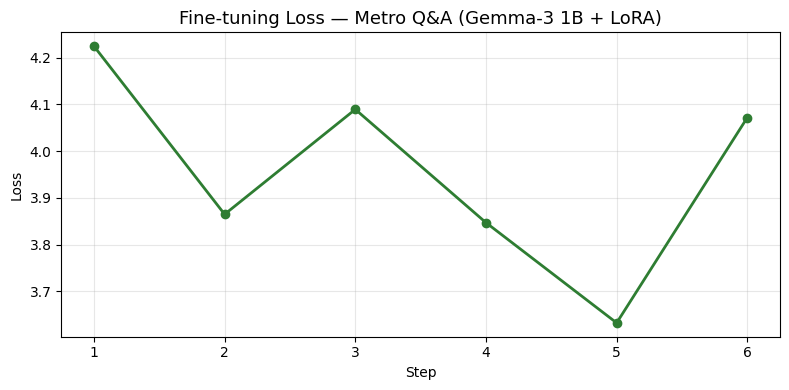

Loss reduced from 4.2245 → 4.0719


In [7]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
steps  = [x["step"] for x in log_history if "loss" in x]
losses = [x["loss"] for x in log_history if "loss" in x]

plt.figure(figsize=(8, 4))
plt.plot(steps, losses, marker="o", linewidth=2, color="#2E7D32")
plt.title("Fine-tuning Loss — Metro Q&A (Gemma-3 1B + LoRA)", fontsize=13)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Loss reduced from {losses[0]:.4f} → {losses[-1]:.4f}")

## 7. Sample Inference

Test the fine-tuned model on new Metro-style questions it hasn't seen during training.

In [8]:
FastLanguageModel.for_inference(model)  # Enable Unsloth's faster inference kernel

TEST_QUESTIONS = [
    "Our department wants to use an AI tool to process permit applications. What compliance questions should we answer before we go live?",
    "How do I find out which Metro department owns a specific parcel of land near the Tualatin River?",
]

for question in TEST_QUESTIONS:
    messages = [{"role": "user", "content": question}]
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
    ).to("cuda")

    outputs = model.generate(
        input_ids=inputs,
        max_new_tokens=300,
        temperature=0.4,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

    response = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)
    print(f"Q: {question}")
    print(f"A: {response}")
    print("-" * 80)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Our department wants to use an AI tool to process permit applications. What compliance questions should we answer before we go live?
A: Okay, let's dive into the compliance questions your department needs to answer before deploying an AI permit application processor. This is a complex area, and you need to ensure the AI is compliant with local, state, and federal regulations. Here’s a breakdown of key areas and questions, broken down by complexity and risk:

**I. Data Privacy & Security (Highest Priority - Critical)**

*   **What data is the AI trained on?** (Be specific: Permit applications, demographics, location, etc.)
*   **Is the data anonymized or pseudonymized?** (If so, how is this maintained? Audit trail?)
*   **What data is the AI trained on?** (Permit application data)
*   **What is the data retention policy?** (How long will the data be stored?)
*   **How is the data protected?** (Encryption, access controls, etc.)
*   **What are the data privacy compliance standards?** 

## 8. Save the LoRA Adapter

Save the adapter weights for later use or merging into the base model.

In [9]:
ADAPTER_PATH = "/tmp/metro-lora-adapter"

model.save_pretrained(ADAPTER_PATH)
tokenizer.save_pretrained(ADAPTER_PATH)

print(f"Adapter saved to {ADAPTER_PATH}")
print("\nTo push to HuggingFace Hub (optional):")
print("  model.push_to_hub('your-username/metro-gemma3-1b-lora')")
print("  tokenizer.push_to_hub('your-username/metro-gemma3-1b-lora')")
print("\nTo export as GGUF for use in Unsloth Studio or Ollama:")
print("  model.save_pretrained_gguf(ADAPTER_PATH, tokenizer, quantization_method='q4_k_m')")

Unsloth: Restored added_tokens_decoder metadata in /tmp/metro-lora-adapter/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /tmp/metro-lora-adapter.


Adapter saved to /tmp/metro-lora-adapter

To push to HuggingFace Hub (optional):
  model.push_to_hub('your-username/metro-gemma3-1b-lora')
  tokenizer.push_to_hub('your-username/metro-gemma3-1b-lora')

To export as GGUF for use in Unsloth Studio or Ollama:
  model.save_pretrained_gguf(ADAPTER_PATH, tokenizer, quantization_method='q4_k_m')


## What's Next

| Step | Action |
|------|--------|
| More data | Run `metro_recipe.json` in Unsloth Studio with `rows: 200` to generate a larger JSONL, then re-run this notebook |
| Better base model | Swap `gemma-3-1b-it` for `unsloth/gemma-3-4b-it` or `unsloth/Qwen2.5-7B-Instruct` for higher quality |
| Deployment | Export as GGUF → import into Ollama → serve locally or via Azure AI Foundry |
| Compliance | Add a `compliance_flag` column to the Recipe for rows touching PII or public records — gate those rows on human review before training |
| Eval | Add a held-out Metro Q&A eval set and measure accuracy before/after fine-tuning |